<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/04_deep_learning/keras/Basic_Keras_MNIST_Practice.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/04_deep_learning/keras/Basic_Keras_MNIST_Practice.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Digit Classification with Keras (MNIST)

## Context
Before jumping into infrastructure-flavored deep learning (time-series LSTMs, log-based models), it helps to build the basic muscle memory for a neural network training loop — define layers, compile, fit, evaluate, predict. MNIST handwritten digits is the classic dataset for this because it's small, fast to train on a CPU, and lets you focus entirely on the Keras API instead of data wrangling.

## Objectives
- Build, compile, and train a simple fully-connected (Dense) network with Keras.
- Evaluate the model and visualize its training curves.
- Get hands-on practice tuning hyperparameters: layer count, learning rate, batch size, optimizer.

## Expected Outcome
- A model that classifies handwritten digits (0-9) at ~97-98% test accuracy.
- Intuition for how each hyperparameter nudges training speed and accuracy, which carries directly into the more complex networks later in this section.

### Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

2026-07-11 17:14:43.549286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 1. Load and Preprocess the Data
Pixel values start as integers 0-255; we scale them to 0-1 (networks train more reliably on small, centered inputs) and flatten each 28x28 image into a 784-length vector since a plain `Dense` network expects 1D input.

In [2]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten the 28x28 images into 1D vectors of size 784
train_images = train_images.reshape((train_images.shape[0], 28 * 28))
test_images = test_images.reshape((test_images.shape[0], 28 * 28))


### 2. Build the Model
A minimal network: one hidden layer of 128 ReLU neurons, then a 10-way softmax output (one probability per digit).

In [3]:
# Build a simple Sequential model
model = Sequential([
    Input(shape=(28 * 28,)),
    Dense(128, activation='relu'),  # First hidden layer with 128 neurons
    Dense(10, activation='softmax')  # Output layer with 10 neurons (one for each digit)
])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compile the Model
Compiling wires up the optimizer (how weights get updated), the loss function (what "wrong" means), and the metrics to track.

In [4]:
# Compile the model with Adam optimizer and categorical cross-entropy loss
model.compile(optimizer='adam',  # Try changing this to 'sgd' or 'rmsprop'
              loss='sparse_categorical_crossentropy',  # You can also try 'mean_squared_error' for regression tasks
              metrics=['accuracy'])


### 4. Train the Model
`verbose=2` prints one summary line per epoch instead of a live-updating progress bar — cleaner to read once the cell output is saved in the notebook.

In [5]:
# Train the model
history = model.fit(train_images, train_labels, epochs=5, batch_size=32,
                     validation_data=(test_images, test_labels), verbose=2)

Epoch 1/5


2026-07-11 17:14:52.472869: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


2026-07-11 17:15:00.139563: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


1875/1875 - 7s - 4ms/step - accuracy: 0.9252 - loss: 0.2621 - val_accuracy: 0.9567 - val_loss: 0.1453


Epoch 2/5


...

1875/1875 - 5s - 3ms/step - accuracy: 0.9760 - loss: 0.0798 - val_accuracy: 0.9735 - val_loss: 0.0894


Epoch 4/5


1875/1875 - 5s - 3ms/step - accuracy: 0.9816 - loss: 0.0600 - val_accuracy: 0.9761 - val_loss: 0.0803


Epoch 5/5


1875/1875 - 5s - 3ms/step - accuracy: 0.9852 - loss: 0.0468 - val_accuracy: 0.9758 - val_loss: 0.0781


### 5. Evaluate the Model
Accuracy on the held-out test set is the number that matters — training accuracy alone can hide overfitting.

In [6]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'Test accuracy: {test_acc}')

2026-07-11 17:15:22.122897: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 - 1s - 2ms/step - accuracy: 0.9758 - loss: 0.0781


Test accuracy: 0.9757999777793884


### 6. Visualize Training Metrics
Plotting accuracy/loss per epoch for both train and validation sets is how you catch overfitting: if validation loss starts climbing while training loss keeps falling, the model has started memorizing instead of generalizing.

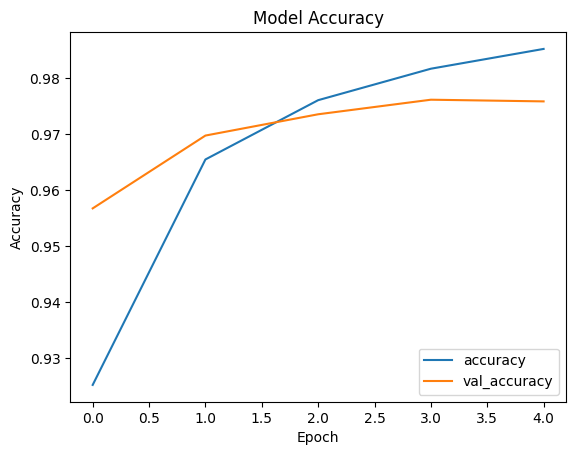

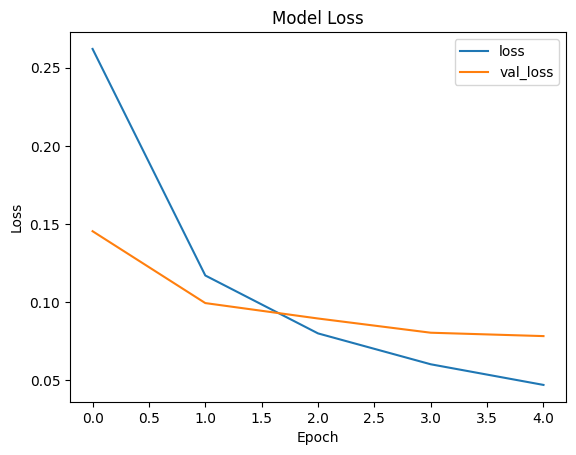

In [7]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Model Loss')
plt.show()

### 7. Make Predictions
Run inference on a single test image and compare the model's top prediction against the picture.

  1/313 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step

 38/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

 72/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-07-11 17:15:23.165321: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


110/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...

213/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

248/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

285/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


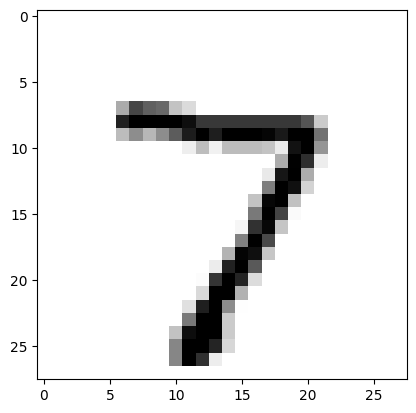

Predicted label: 7


In [8]:
# Predict on the first image in the test dataset
predictions = model.predict(test_images)

# Display the first test image and its predicted label
plt.imshow(test_images[0].reshape(28, 28), cmap=plt.cm.binary)
plt.show()

# Print the predicted class
predicted_label = predictions[0].argmax()  # Get the index of the highest predicted probability
print(f'Predicted label: {predicted_label}')


## Try It Yourself: Experiment with Hyperparameters
The cells below are a sandbox for building intuition about how each knob affects training — they reassign `model` and aren't meant to feed back into the plots above. If you change something and want to see the effect on the accuracy/loss curves, re-run cells 4-6 afterward (or duplicate them below).

**Change the number of layers:**

In [9]:
model = Sequential([
    Input(shape=(28 * 28,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),  # Add another hidden layer
    Dense(10, activation='softmax')
])

**Adjust the learning rate:**

In [10]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)  # Try different values for learning rate
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


**Change batch size** — this actually retrains, so you can compare the result against the original run above:

In [11]:
# Try different batch sizes and compare against the original batch_size=32 run
history_bs64 = model.fit(train_images, train_labels, epochs=5, batch_size=64,
                          validation_data=(test_images, test_labels), verbose=2)

print(f"\nFinal val_accuracy — batch_size=32: {history.history['val_accuracy'][-1]:.4f}, "
      f"batch_size=64: {history_bs64.history['val_accuracy'][-1]:.4f}")

Epoch 1/5


2026-07-11 17:15:24.758311: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


938/938 - 4s - 4ms/step - accuracy: 0.9214 - loss: 0.2760 - val_accuracy: 0.9608 - val_loss: 0.1327


Epoch 2/5


938/938 - 5s - 6ms/step - accuracy: 0.9660 - loss: 0.1152 - val_accuracy: 0.9699 - val_loss: 0.0983


...

Epoch 4/5


938/938 - 3s - 4ms/step - accuracy: 0.9819 - loss: 0.0601 - val_accuracy: 0.9749 - val_loss: 0.0759


Epoch 5/5


938/938 - 3s - 4ms/step - accuracy: 0.9849 - loss: 0.0469 - val_accuracy: 0.9778 - val_loss: 0.0727



Final val_accuracy — batch_size=32: 0.9758, batch_size=64: 0.9778


**Try different optimizers** — these just swap the optimizer config; call `.fit(...)` again yourself to see the effect:

SGD

In [12]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


RMSprop

In [13]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


## Summary & Next Steps
You built, trained, and evaluated a Dense network on MNIST, then tuned it by hand. A few directions to keep exploring:

- **Layers and neurons:** more capacity can improve fit, but watch for overfitting (validation loss rising while training loss keeps falling).
- **Batch size:** smaller batches mean noisier but more frequent gradient updates; larger batches train faster per epoch but need more memory.
- **Activation functions:** try `tanh`, `sigmoid`, or `elu` in place of `relu` and see how convergence speed changes.
- **Optimizer and learning rate:** these have the single biggest impact on how quickly (and whether) training converges — this is usually the first thing worth tuning on a new problem.

From here, the rest of `04_deep_learning/` builds on these same fit/evaluate/predict mechanics with architectures suited to sequential and infrastructure-style data (see `05_timeseries_lstm.ipynb`).